# **`Maranatha.jl`** :: Quick Start

This notebook demonstrates the minimal workflow for using **`Maranatha.jl`**
to perform **deterministic numerical quadrature** with automatic
error estimation and continuum extrapolation.

Unlike Monte-Carlo integration methods such as VEGAS, **`Maranatha.jl`** evaluates the integral
using deterministic quadrature rules and estimates the truncation error
from derivative information. Multiple resolutions are then combined
to extrapolate the integral value in the **zero step-size limit** ($h \to 0$).

The typical workflow is:

1. Define the **integrand** and **integration domain**
2. Run quadrature at several **resolutions**
3. Fit the convergence behaviour as $h \to 0$
4. Visualize the convergence and extrapolation result

This notebook walks through that full pipeline with a minimal example.

## Initialize the Julia environment

Before running the example we load the **`Maranatha.jl`** package.

`using Maranatha` loads the package and all required modules.

If the package is not installed yet, it can be added via

```julia
using Pkg
Pkg.add("Maranatha")
```

In [1]:
using Maranatha


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Define the integration problem

Next we specify the numerical integration problem.

In a typical **`Maranatha.jl`** workflow this includes

- the **integrand function**
- the **integration bounds**
- a sequence of **quadrature resolutions** $N$
- optional **method parameters** such as the quadrature rule
  or error estimation strategy.

For convenience, this notebook loads these settings from a
TOML configuration file, `sample_1d.toml`:

```julia
[integrand]
file = "sample_1d.jl"
name = "integrand"

[domain]
a = 0.0
b = 3.141592653589793
dim = 1

[sampling]
nsamples = [2, 3, 4, 5, 6, 7, 8, 9]

[quadrature]
rule = "gauss_p4"
boundary = "LU_EXEX"

[error]
err_method = "refinement"
fit_terms = 4
nerr_terms = 3
ff_shift = 0

[execution]
use_error_jet = true

[output]
name_prefix = "sample_1d"
save_path = "jld2"
write_summary = true
save_file = true
```

Here, it is written as
```julia
integrand(x) = sin(x)
```
in  `sample_1d.jl`.

Using a configuration file such as `sample_1d.toml` keeps the numerical setup
separate from the analysis code and makes experiments easier to reproduce.

## Run the quadrature pipeline

The function `run_Maranatha` executes the full quadrature workflow.

For each resolution $N$ specified in the configuration file it:

1. computes the quadrature estimate of the integral
2. evaluates the derivative-based truncation error model
3. records the result as a function of the step size

$$
h = \frac{b-a}{N}
$$

The returned object (`run_result`) contains the full dataset
needed for later analysis, including

- step sizes
- quadrature estimates
- estimated errors

These data points will later be used to extrapolate the integral
to the continuum limit $h \to 0$.

In [2]:
toml_path = "../samples/sample_1d.toml"

toml_dir = dirname(toml_path)

Maranatha.Utils.JobLoggerTools.log_stage_benji("BEGIN run_Maranatha")

run_result = run_Maranatha(toml_path)

Maranatha.Utils.JobLoggerTools.log_stage_benji("END run_Maranatha")

[2026-03-18 23:19:47.390] 
[2026-03-18 23:19:47.515] ==================================================
[2026-03-18 23:19:47.515] >>> BEGIN run_Maranatha
[2026-03-18 23:19:47.515] ==================================================
[2026-03-18 23:19:47.515] 
[2026-03-18 23:20:04.160] 
[2026-03-18 23:20:04.161] ==================================================
[2026-03-18 23:20:04.161] >>> Start run_Maranatha
[2026-03-18 23:20:04.161] ==================================================
[2026-03-18 23:20:04.161] 
[2026-03-18 23:20:08.585] 
[2026-03-18 23:20:08.585] ==================================================
[2026-03-18 23:20:08.585] >>> END run_Maranatha
[2026-03-18 23:20:08.585] ==================================================
[2026-03-18 23:20:08.585] 


## Alternative: Do `run_Maranatha` directly from Julia

Instead of using a TOML configuration file, the integration
problem can also be defined **directly in Julia code**.

This approach is convenient for quick experimentation,
interactive exploration, or when embedding **`Maranatha.jl`**
inside a larger Julia program.

In this example we specify

- the integrand
- the integration bounds
- the quadrature resolutions
- method and fitting options

directly as Julia variables and pass them to `run_Maranatha`.

In [3]:
integrand2(x) = sin(x)

bounds = (0.0, π)
dim = 1

ns = [2, 3, 4, 5, 6, 7, 8, 9]
ns .+= 0

rule = :gauss_p4
boundary = :LU_EXEX

err_method = :forwarddiff # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation

fit_terms = 4
nerr_terms = 3
ff_shift = 0

use_error_jet = false

result_string = "sample_1d"
result_string_direct = "sample_1d_direct"

save_path = joinpath(toml_dir, "jld2")
write_summary = true
save_file = true

Maranatha.Utils.JobLoggerTools.log_stage_benji("BEGIN run_Maranatha")

run_result_direct = run_Maranatha(
    integrand2,
    bounds...;
    dim = dim,
    nsamples = ns,
    rule = rule,
    boundary = boundary,
    err_method = err_method,
    fit_terms = fit_terms,
    nerr_terms = nerr_terms,
    ff_shift = ff_shift,
    use_error_jet = use_error_jet,
    name_prefix = result_string_direct,
    save_path = save_path,
    write_summary = write_summary
)

Maranatha.Utils.JobLoggerTools.log_stage_benji("END run_Maranatha")

[2026-03-18 23:20:08.838] 
[2026-03-18 23:20:08.838] ==================================================
[2026-03-18 23:20:08.838] >>> BEGIN run_Maranatha
[2026-03-18 23:20:08.838] ==================================================
[2026-03-18 23:20:08.838] 
[2026-03-18 23:20:09.872] 
[2026-03-18 23:20:09.872] ==================================================
[2026-03-18 23:20:09.873] >>> Start run_Maranatha
[2026-03-18 23:20:09.873] ==================================================
[2026-03-18 23:20:09.873] 
[2026-03-18 23:20:15.738] 
[2026-03-18 23:20:15.738] ==================================================
[2026-03-18 23:20:15.738] >>> END run_Maranatha
[2026-03-18 23:20:15.738] ==================================================
[2026-03-18 23:20:15.738] 


### Tag outputs for Lesson 1

To avoid overwriting files,
we append a lesson-specific suffix to the result name.

This modified identifier will be used by downstream functions
(such as plotting or report generation) when constructing
output filenames.

In [4]:
result_string = "lesson1_" * result_string
resut_string_direct = "lesson1_" * result_string_direct

"lesson1_sample_1d_direct"

## Perform continuum extrapolation

Once quadrature data are obtained at multiple resolutions,
we estimate the continuum limit $h \to 0$.

**`Maranatha.jl`** performs this using a **weighted least $\chi^2$ fit**
based on the expected convergence behaviour of the quadrature rule.

The simplest call uses the default fitting configuration.

In [5]:
fit_result = least_chi_square_fit(run_result)

print_fit_result(fit_result)

[2026-03-18 23:20:21.367] residual ks (backend) = [8, 10, 12, 14], fit powers (h^p), ff_shift=0 = [8, 10, 12]
[2026-03-18 23:20:23.533]            λ_0 = 2.00000000000000(35)
[2026-03-18 23:20:23.533]            λ_1 = -0.0000000011(12) *
[2026-03-18 23:20:23.533]            λ_2 = -0.0000000000(29) *
[2026-03-18 23:20:23.533]            λ_3 = -0.0000000000(11) *
[2026-03-18 23:20:23.533] 
[2026-03-18 23:20:23.533] Chi^2 / d.o.f. = 1.090602717544e-05 / 4 = 2.726506793859e-06
[2026-03-18 23:20:23.533] Result (h→0)   = 2.00000000000000(35)
[2026-03-18 23:20:23.533] 


### Explicit fitting call (advanced usage)

The convenience method
```julia
least_chi_square_fit(run_result)
```
extracts all required information automatically from the
`run_result` object.

For advanced use cases, the fitting routine can also be
called explicitly by passing the individual data fields.
This provides full control over the fitting inputs and
can be useful when performing custom analyses.

In [6]:
fit_result_direct = least_chi_square_fit(
    run_result_direct.a,
    run_result_direct.b,
    run_result_direct.h,
    run_result_direct.avg,
    run_result_direct.err,
    run_result_direct.rule,
    run_result_direct.boundary;
    nterms=fit_terms,
    ff_shift=ff_shift,
    nerr_terms=nerr_terms
)

print_fit_result(fit_result_direct)

[2026-03-18 23:20:23.895] residual ks (backend) = [8, 10, 12, 14], fit powers (h^p), ff_shift=0 = [8, 10, 12]
[2026-03-18 23:20:23.937]            λ_0 = 2.00000000000000(15)
[2026-03-18 23:20:23.937]            λ_1 = -0.00000000113(67)
[2026-03-18 23:20:23.937]            λ_2 = -0.0000000000(20) *
[2026-03-18 23:20:23.937]            λ_3 = -0.00000000000(79) *
[2026-03-18 23:20:23.937] 
[2026-03-18 23:20:23.937] Chi^2 / d.o.f. = 3.502341718847e-05 / 4 = 8.755854297117e-06
[2026-03-18 23:20:23.937] Result (h→0)   = 2.00000000000000(15)
[2026-03-18 23:20:23.937] 


### Customizing the fit model

In most situations it is not necessary to call the fitting routine
with all arguments explicitly. The convenience interface

```julia
least_chi_square_fit(run_result; ...)
```

already exposes the most important fitting controls.

The extrapolation model can be adjusted through several parameters.

- `nterms`  
  Number of convergence terms included in the fit ansatz.

- `ff_shift`  
  Optional fitting function shift of the convergence powers.

- `nerr_terms`  
  Number of residual terms used in the derivative-based
  error model.

These options allow more flexible fits when higher-order
effects become visible in the data.

In [7]:
fit_nterms = 4
fit_nerr_terms = 3

fit_result = least_chi_square_fit(
    run_result; 
    nterms=fit_nterms, 
    ff_shift=0, 
    nerr_terms=fit_nerr_terms
)

print_fit_result(fit_result)

[2026-03-18 23:20:23.953] residual ks (backend) = [8, 10, 12, 14], fit powers (h^p), ff_shift=0 = [8, 10, 12]
[2026-03-18 23:20:23.953]            λ_0 = 2.00000000000000(35)
[2026-03-18 23:20:23.953]            λ_1 = -0.0000000011(12) *
[2026-03-18 23:20:23.953]            λ_2 = -0.0000000000(29) *
[2026-03-18 23:20:23.953]            λ_3 = -0.0000000000(11) *
[2026-03-18 23:20:23.953] 
[2026-03-18 23:20:23.953] Chi^2 / d.o.f. = 1.090602717544e-05 / 4 = 2.726506793859e-06
[2026-03-18 23:20:23.953] Result (h→0)   = 2.00000000000000(35)
[2026-03-18 23:20:23.953] 


## Visualize convergence

Finally we visualize how the quadrature estimates behave
as the step size $h$ decreases.

The convergence plot typically shows:

- quadrature estimates at different resolutions
- estimated error bars
- the extrapolated value obtained from the fit
- the expected convergence slope of the quadrature rule

Such plots provide a quick visual diagnostic of whether the
numerical integration behaves as expected.

The figure will be saved to disk when `save_file = true`.

This allows the convergence plots to be archived together with
the numerical results for later analysis or publication.

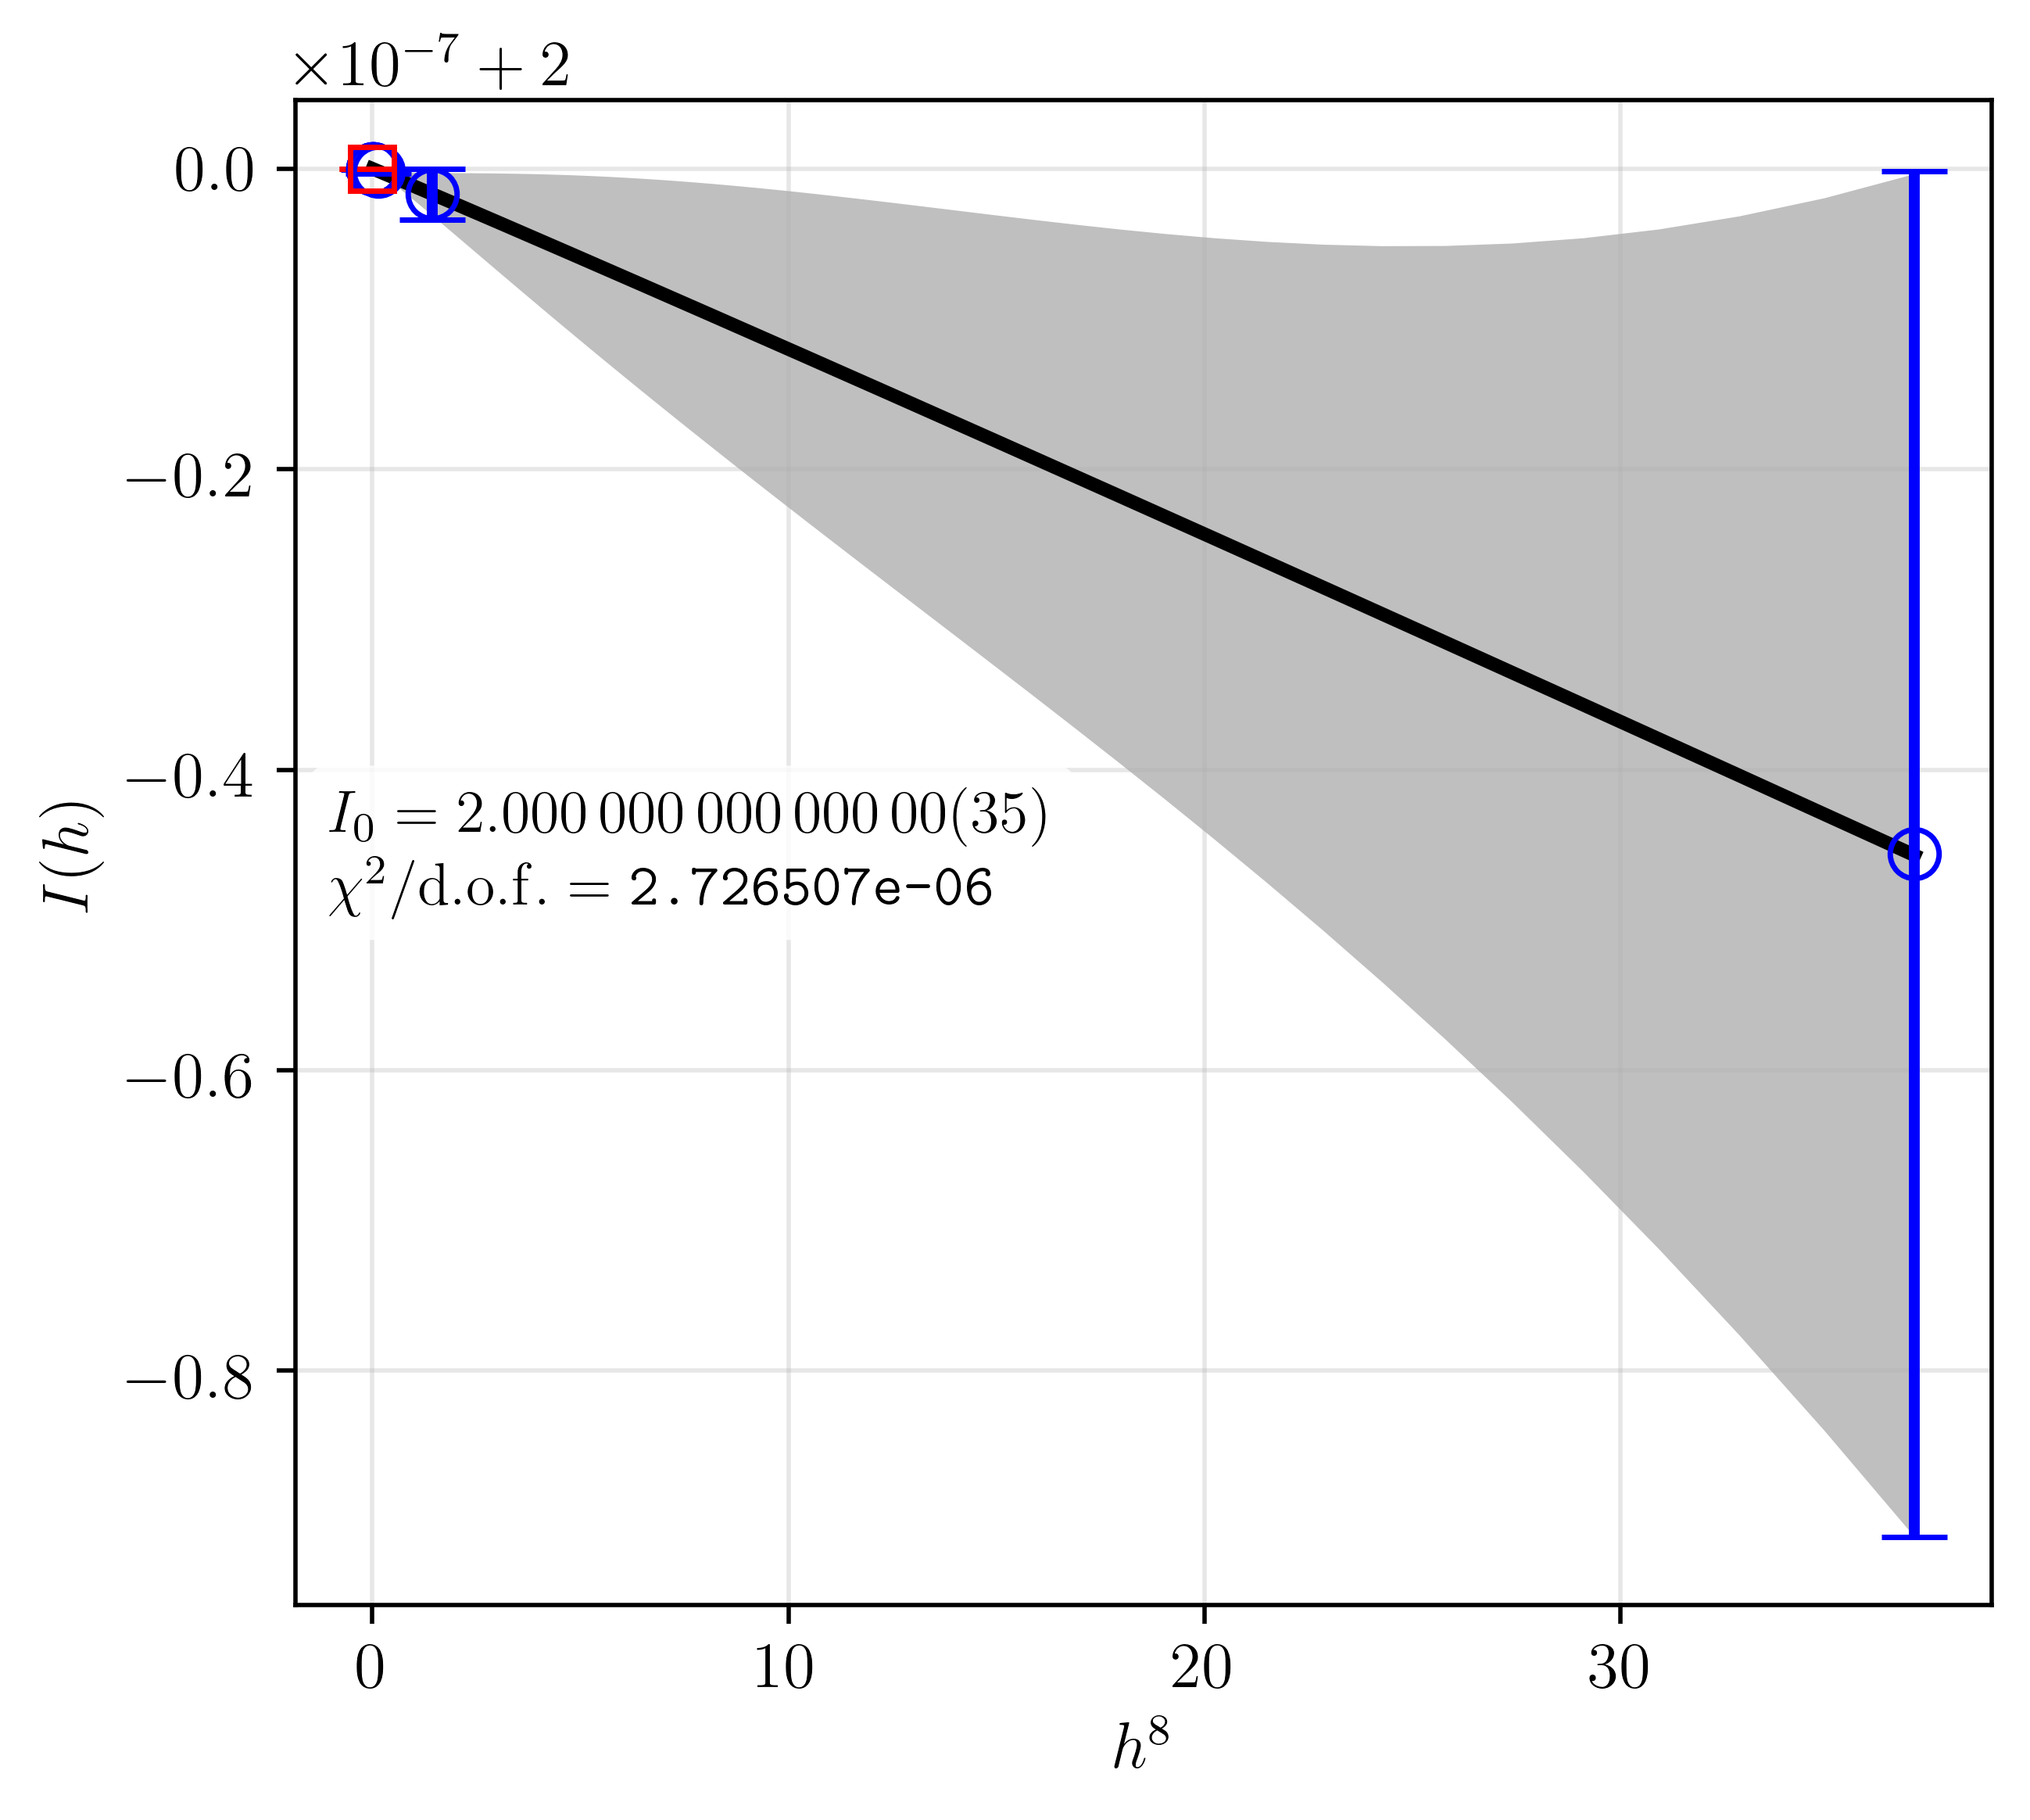

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson1_sample_1d_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson1_sample_1d_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


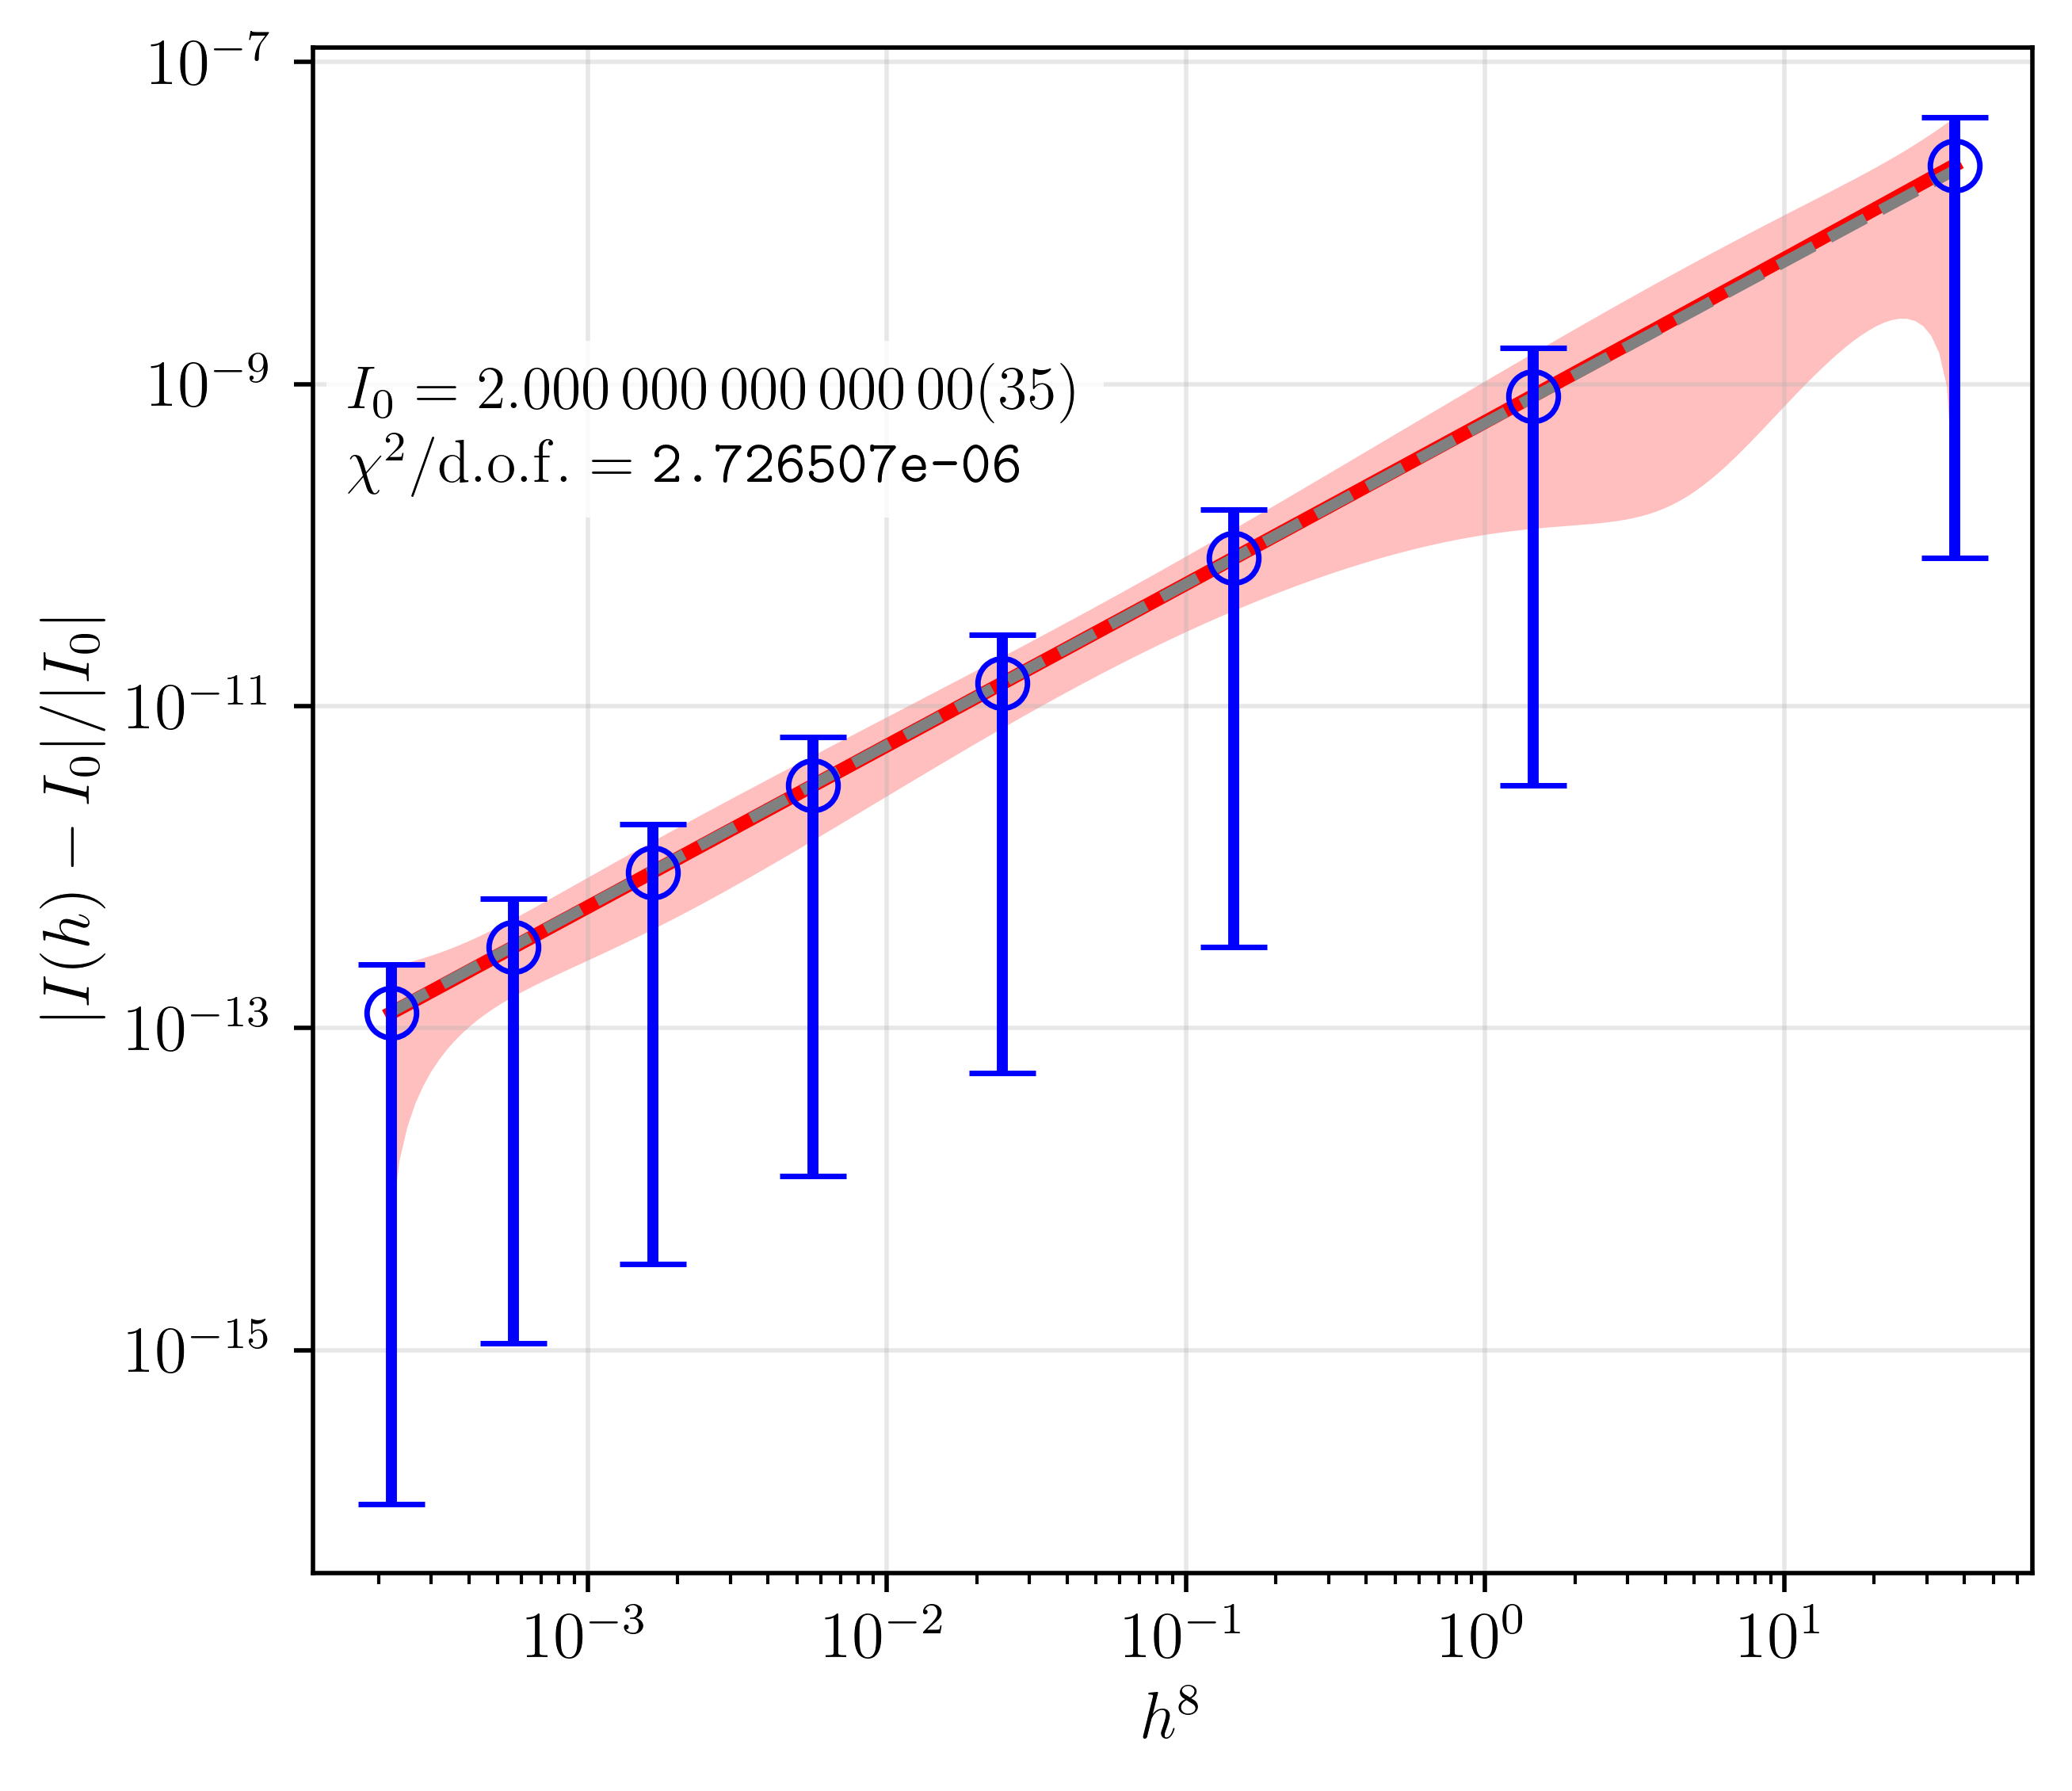

In [8]:
plot_convergence_result(
    run_result, 
    fit_result;
    name=result_string,
    figs_dir=save_path,
    save_file=true
)

### Explicit plotting call (advanced usage)

Similar to the fitting routine, the plotting function also provides
a convenience interface that accepts the `run_result` object.

For advanced use cases, the plotting routine can be called explicitly
by passing the individual data arrays. This can be useful when working
with externally loaded data or custom datasets.

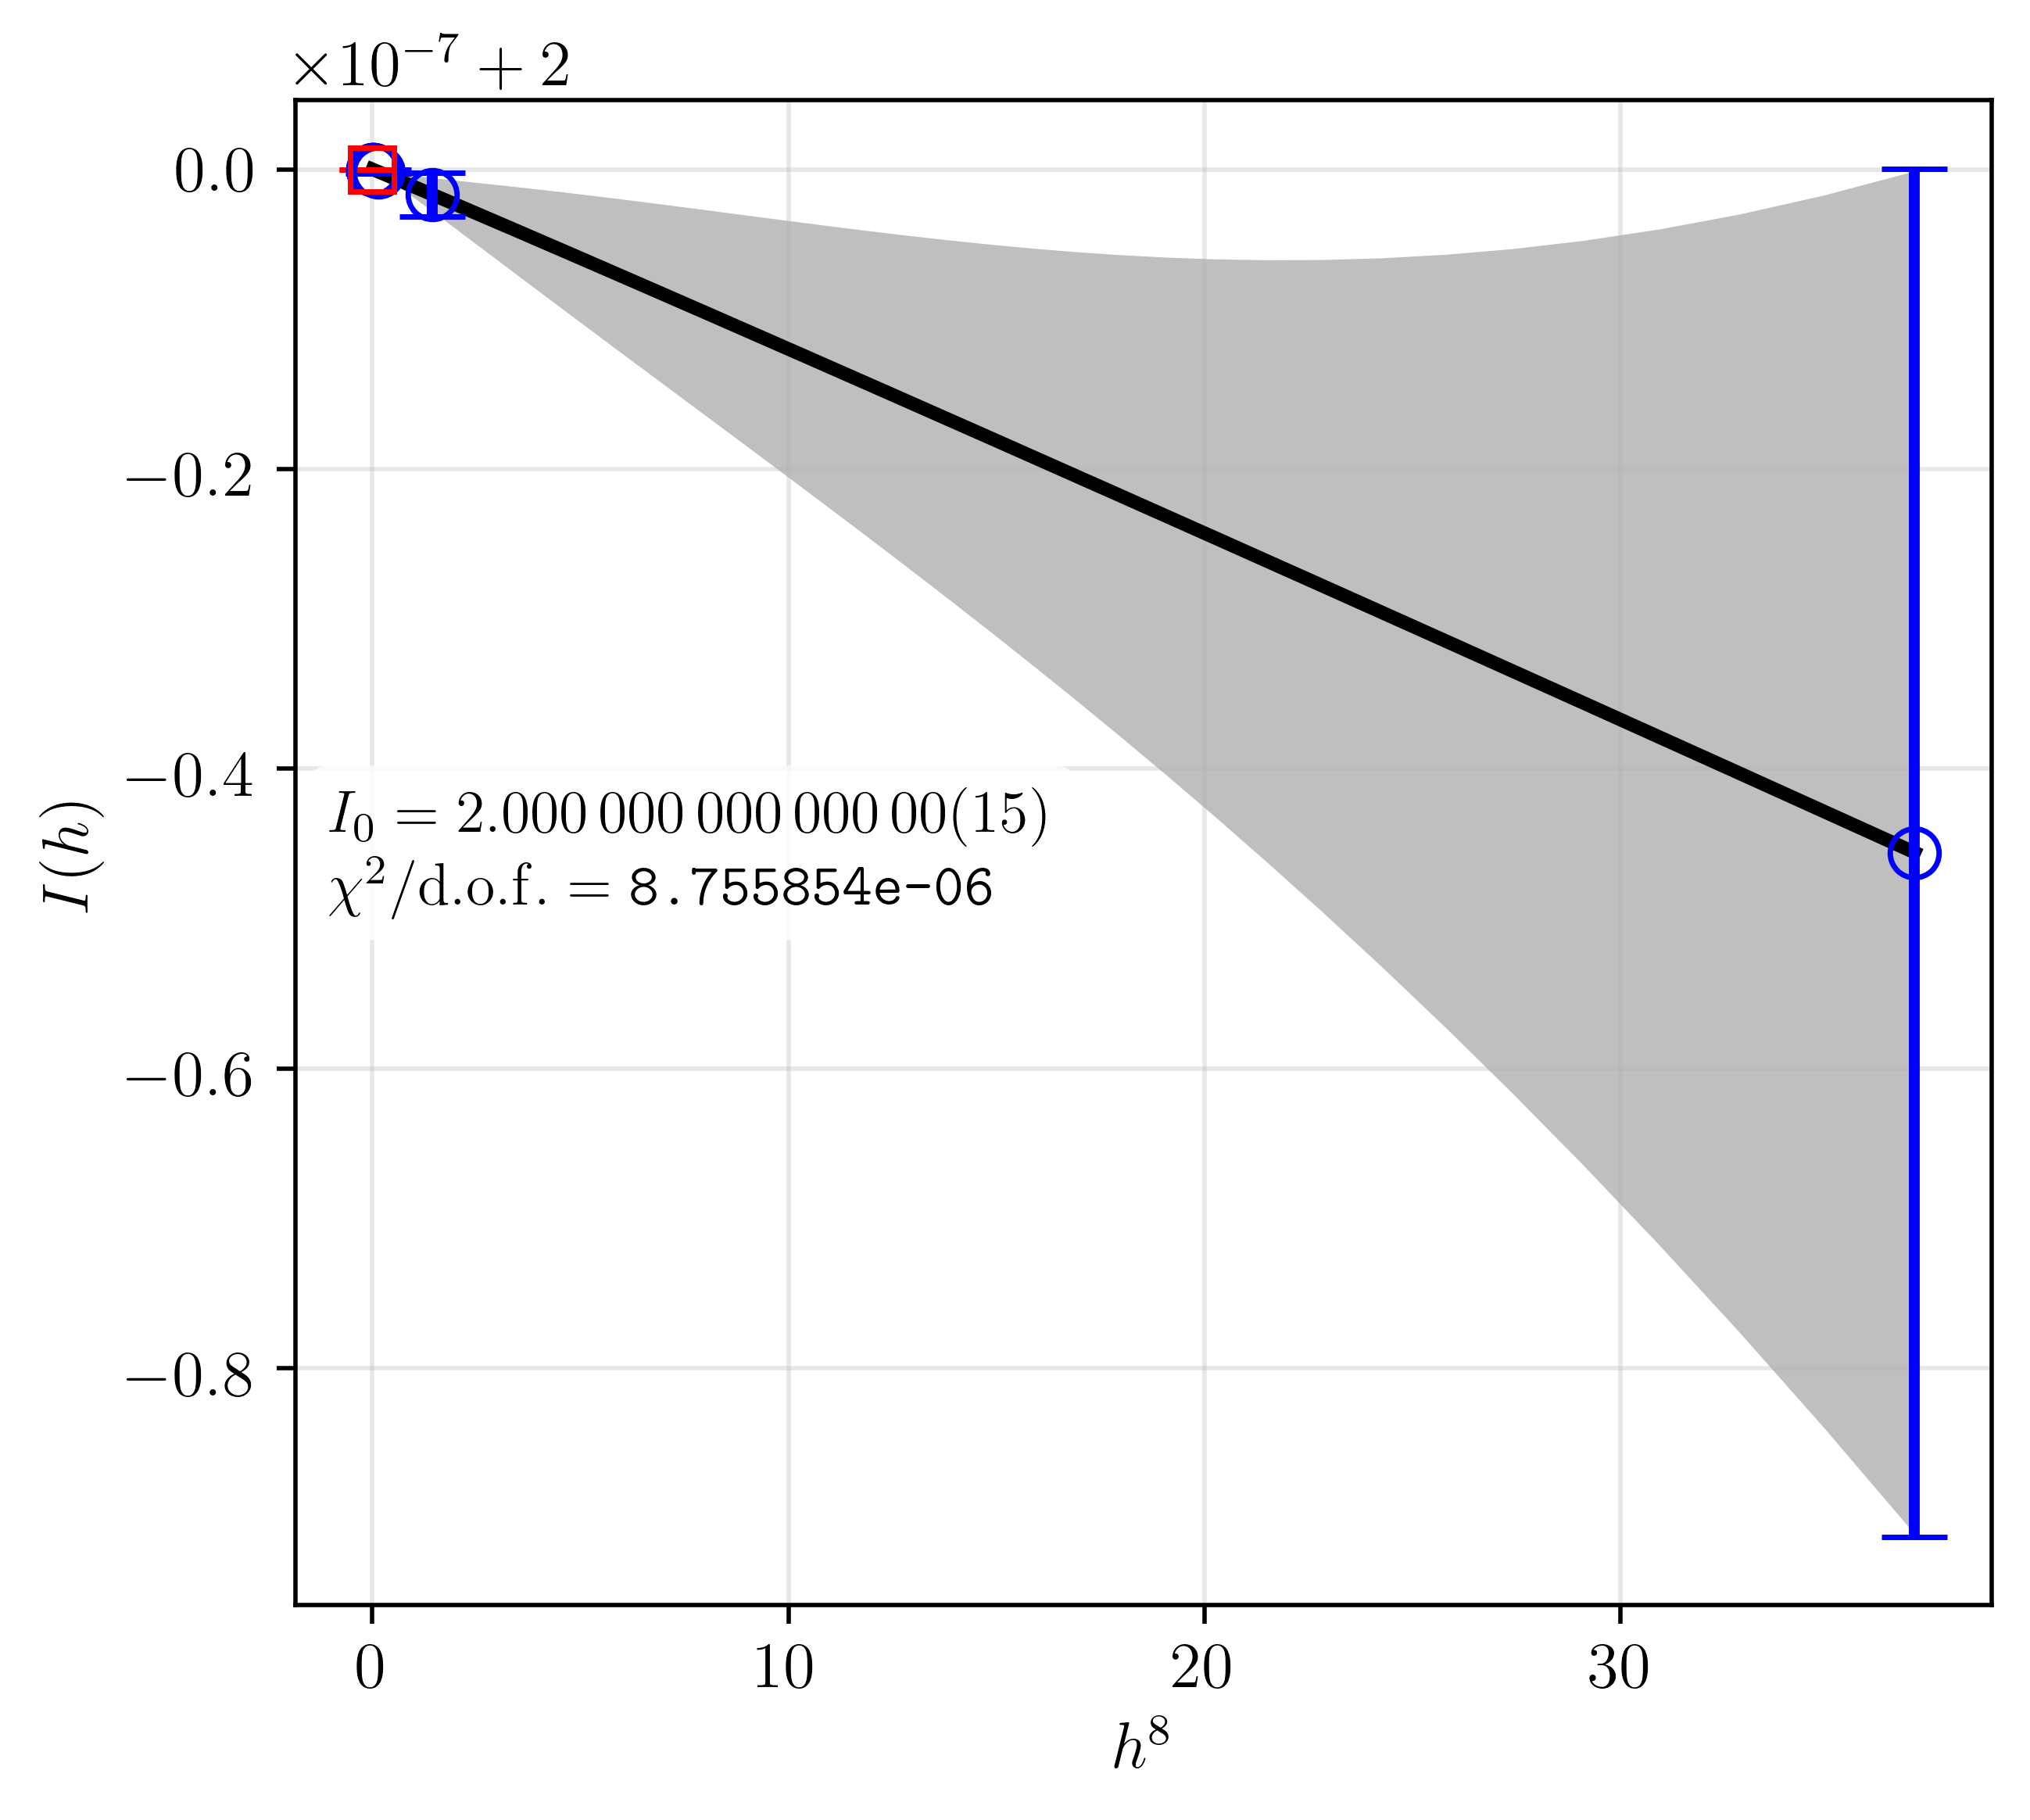

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_sample_1d_direct_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_sample_1d_direct_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


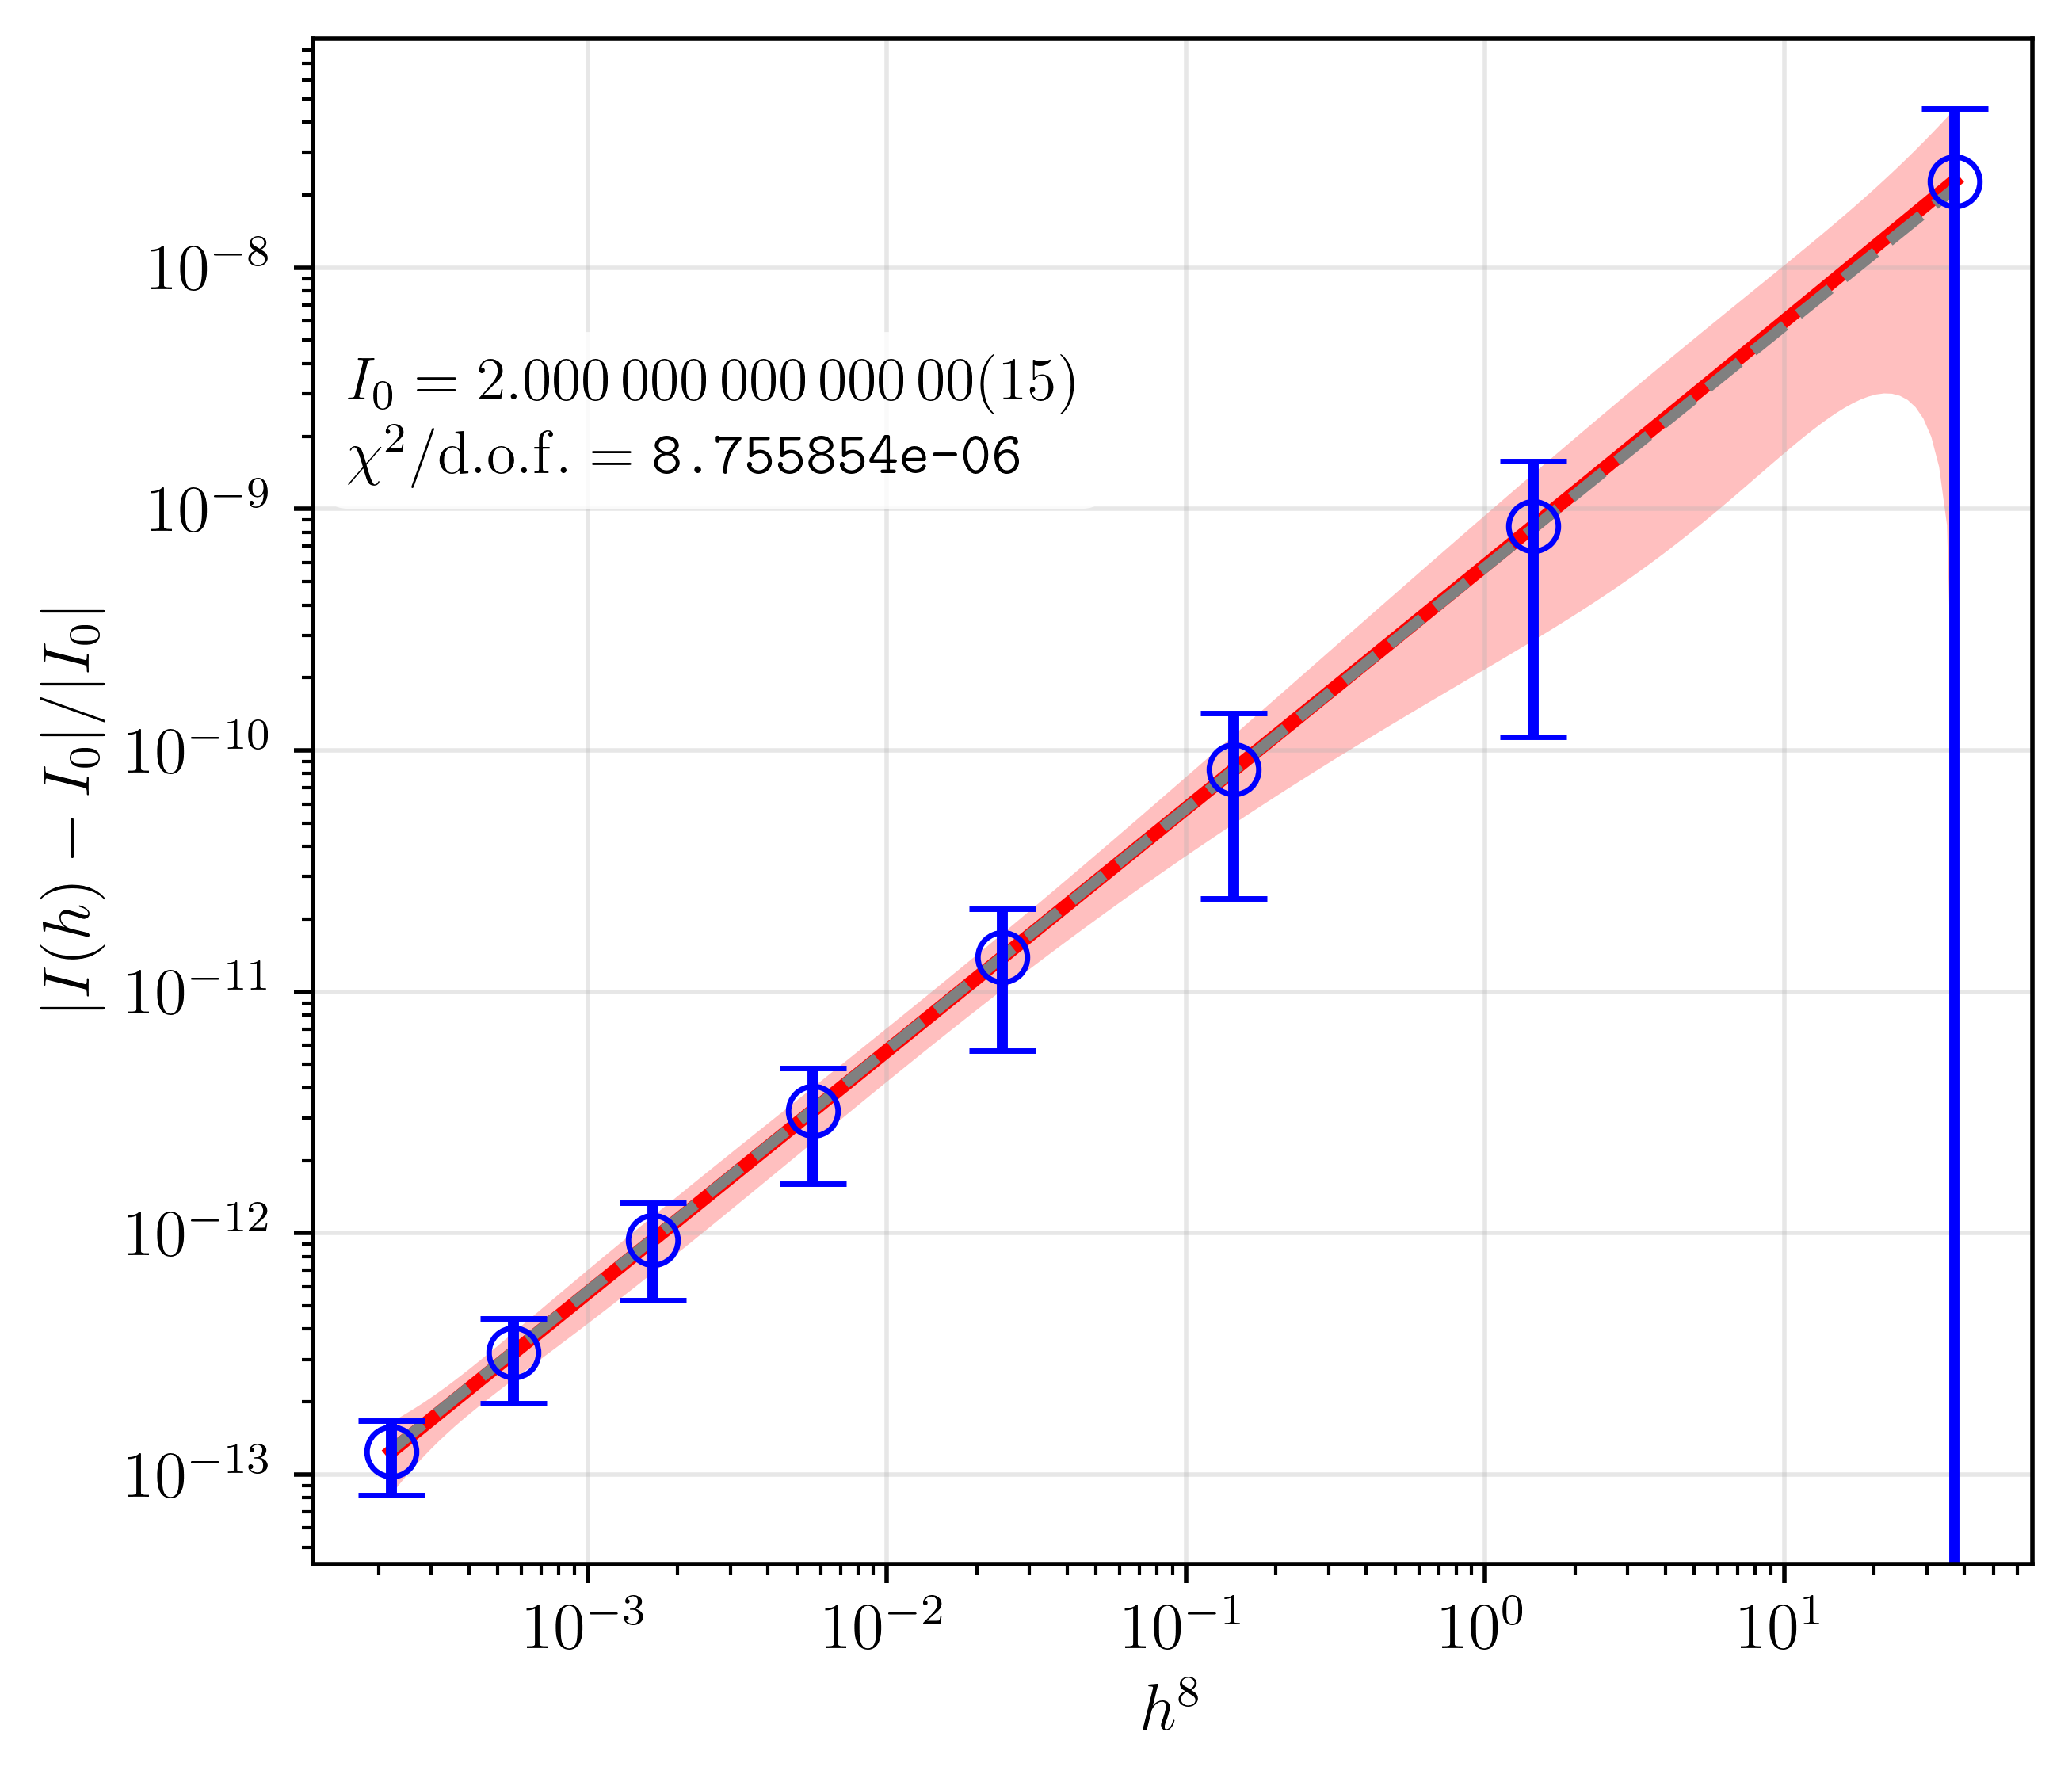

In [9]:
plot_convergence_result(
    bounds..., 
    result_string_direct, 
    run_result_direct.h, 
    run_result_direct.avg, 
    run_result_direct.err, 
    fit_result_direct; 
    rule=run_result_direct.rule, 
    boundary=run_result_direct.boundary,
    figs_dir=save_path,
    save_file=save_file
)

After visualization, the same result can be exported into structured summary
and report-oriented formats for reproducible documentation.

## Export a convergence summary

Once the quadrature data, fit result, and diagnostic plots have been generated,
it is often useful to export a compact written summary of the analysis.

`Maranatha.jl` provides `write_convergence_summary` for this purpose.

This utility converts the numerical result into a structured summary that can be
saved in a document-friendly format such as Markdown. It is useful when you want to

- keep a lightweight record of a convergence study,
- inspect fitted values and metadata outside the Julia session,
- archive analysis results alongside generated figures,
- prepare material for notes, reports, or later comparison studies.

In a typical workflow, this is the first reporting step after fitting and plotting.

The example below writes a Markdown summary of the current run to the output directory.

In [10]:
write_convergence_summary(
    run_result,
    fit_result;
    name = result_string,
    format = :md,
    out_dir = save_path,
    save_file = true,
    nterms = fit_nterms,
    nerr_terms = fit_nerr_terms,
)

"# Convergence summary: lesson1_sample_1d\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Number of error terms |\n|:--|:--|:--|\n| `[0.0, 3.141592653589793]` | `gauss_p4 (LU_EXEX)` | `3` |\n\n## Quadrature estimates and uncertainties for different step sizes\n\n| \$h\$ | \$h^8\$ | \$I" ⋯ 651 bytes ⋯ "lambda_2 h^{10} + \\lambda_3 h^{12}\n```\n\n| parameter | fit result |\n|:--|:--|\n| \$\\lambda_0\$ | **2.00000000000000(35)** |\n| \$\\lambda_1\$ | -0.0000000011(12) * |\n| \$\\lambda_2\$ | -0.0000000000(29) * |\n| \$\\lambda_3\$ | -0.0000000000(11) * |\n| \$\\chi^2 / \\text{d.o.f.}\$ | `2.726507e-06` |\n"

## Generate a full internal note project

For more complete documentation, `Maranatha.jl` can also generate a full
internal-note style report project.

This is handled by `write_convergence_internal_note`, which assembles a
self-contained reporting directory for the current numerical experiment.
Depending on the settings, this may include

- a master LaTeX document,
- summary tables,
- figure include files,
- copied or organized plot assets,
- a reproducible build layout,
- optional automatic PDF compilation.

This workflow is especially useful when you want to turn a numerical test into a
shareable research artifact rather than just a plot or terminal output.

In other words, while `write_convergence_summary` produces a compact written
record, `write_convergence_internal_note` is aimed at reproducible documentation
and report generation.

The example below generates such an internal note project for the current run.

In [11]:
note_info = write_convergence_internal_note(
    run_result,
    fit_result;
    name = result_string,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
    nterms=fit_nterms, 
    nerr_terms=fit_nerr_terms,
    # author = "Benjamin J. Choi",
    # affiliation = "Center for Computational Sciences, University of Tsukuba, 1-1-1 Tennodai, Tsukuba, Ibaraki 305-8577, Japan",
    # abstract_text = "This note summarizes the convergence study and fitted extrapolation result."
)

pdflatex inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/a

(note_dir = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3", figs_dir = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/figs", summary_tex_path = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3_table.tex", fig_tex_path = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3_figs.tex", master_tex_path = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3.tex", makefile_path = "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/Makefile", moved_plots = ["../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/figs/result_lesson1_sample_1d_gauss_p4_LU_EXEX_extrap.pdf", "../samples/jld2/inote_summary_lesson1_sample_1d_gauss_p4_LU_EXEX_ff_4_er_3/figs/result_

## Summary

In this notebook we demonstrated the basic **`Maranatha.jl`** workflow:

1. Define an integration problem
2. Run quadrature at multiple resolutions
3. Perform continuum extrapolation
4. Visualize convergence behavior
5. Export structured summaries and reporting artifacts

For more advanced workflows, **`Maranatha.jl`** also supports:

- custom quadrature rules
- higher-dimensional integrals
- alternative error estimation methods
- document-oriented reporting utilities